# Natural Language Processing Project

In this NLP project we will be attempting to classify Yelp Reviews into 1 star to 5 star categories based off the text content in the reviews. 

We will use the [Yelp Review Data Set from Kaggle](https://www.kaggle.com/c/yelp-recsys-2013).

Each observation in this dataset is a review of a particular business by a particular user.

The "stars" column is the number of stars (1 through 5) assigned by the reviewer to the business. (Higher stars is better.) In other words, it is the rating of the business by the person who wrote the review.

The "cool" column is the number of "cool" votes this review received from other Yelp users. 

All reviews start with 0 "cool" votes, and there is no limit to how many "cool" votes a review can receive. In other words, it is a rating of the review itself, not a rating of the business.

The "useful" and "funny" columns are similar to the "cool" column.

Let's get started!

In [2]:
# Importing the usual suspects
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# THE DATA

In [3]:
yelp = pd.read_csv('yelp.csv') # Reading in the data
yelp.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [3]:
# Seeking info on data
yelp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


**Create a new column called "text length" which is the number of words in the text column.**

To see whether long reviews are blabbering or solid feedbacks :p

In [85]:
yelp['text length'] = yelp['text'].apply(len) # Adding a new column for text length


# EDA

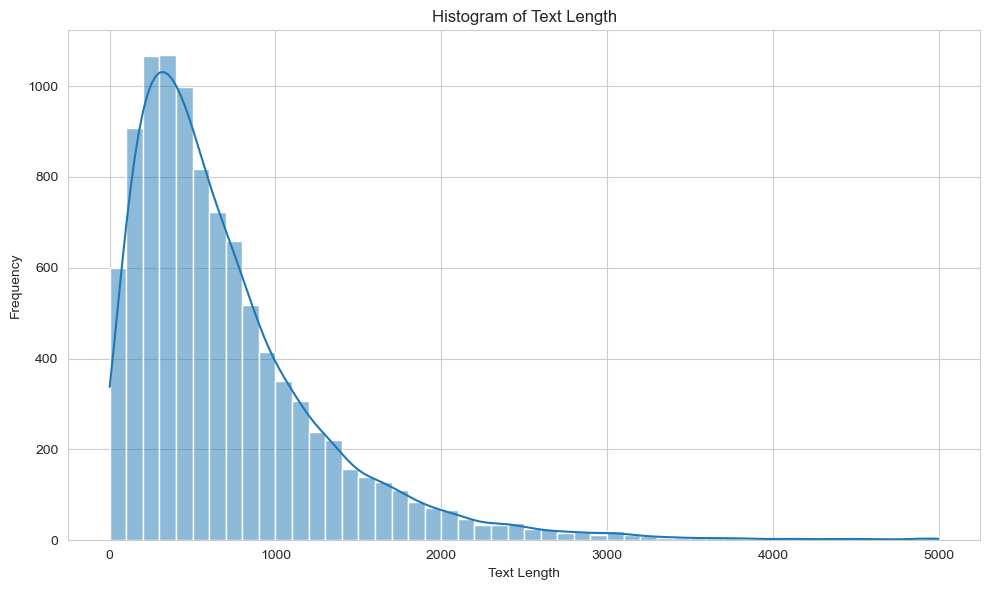

In [27]:
# Plotting a histogram of text length
plt.figure(figsize=(10, 6))
sns.histplot(yelp['text length'], bins=50, kde=True)
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

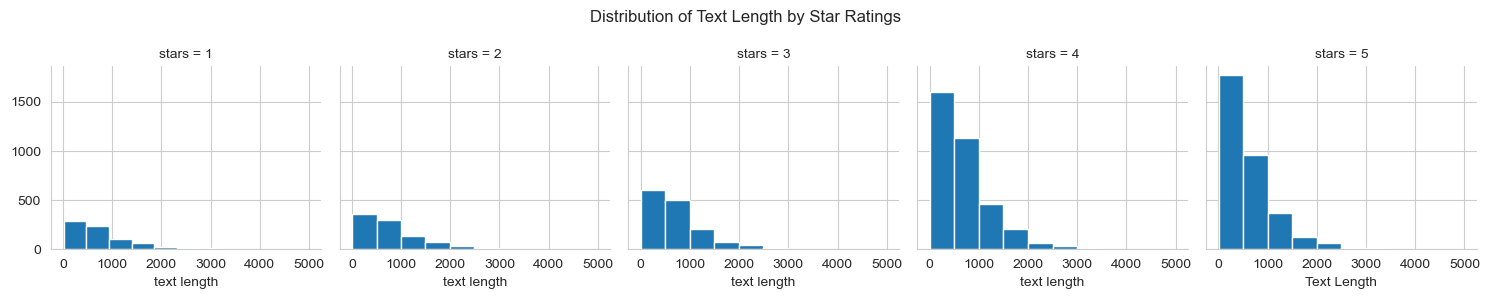

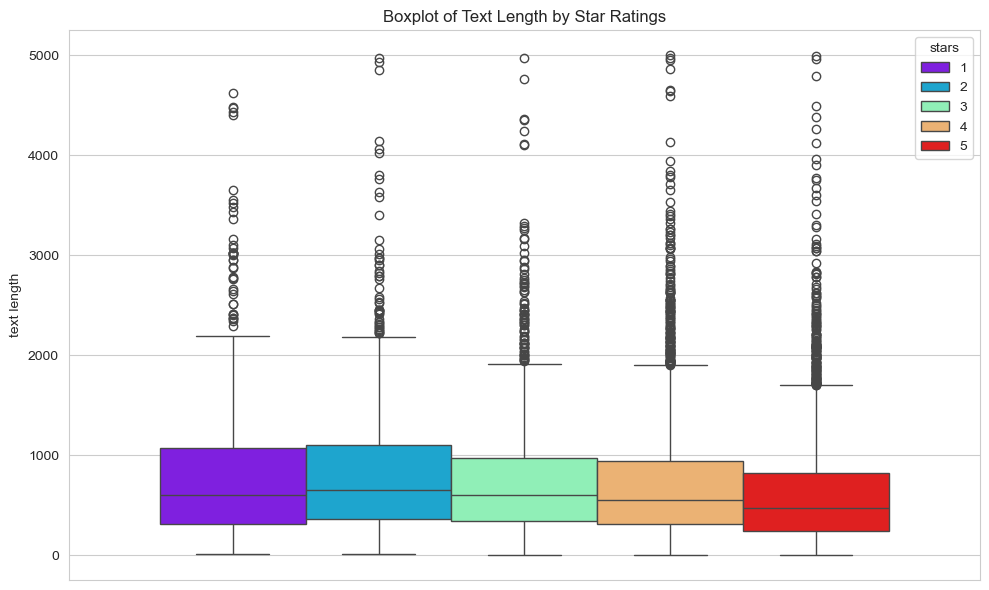

In [29]:
# Lets create 5 histograms of text length based off of the star ratings in different columns
sns.set_style('whitegrid')
g = sns.FacetGrid(yelp, col='stars')
g.map(plt.hist,'text length')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution of Text Length by Star Ratings')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Creating a boxplot of text length for each star category
plt.figure(figsize=(10, 6))
sns.boxplot(y='text length', data=yelp, hue='stars', palette='rainbow')
plt.title('Boxplot of Text Length by Star Ratings')
plt.tight_layout()
plt.show()


In [8]:
# Mean text lengths for each star category
mean_text_length = yelp.groupby('stars')['text length'].mean()
print('Mean Text Lengths for Each Star Category')
print(mean_text_length)

Mean Text Lengths for Each Star Category
stars
1    826.515354
2    842.256742
3    758.498289
4    712.923142
5    624.999101
Name: text length, dtype: float64


Observation :
1. Text length is right skewed
2. Higher ratings observe short crisp texts.

Countplot of the no of occurances of each star rating

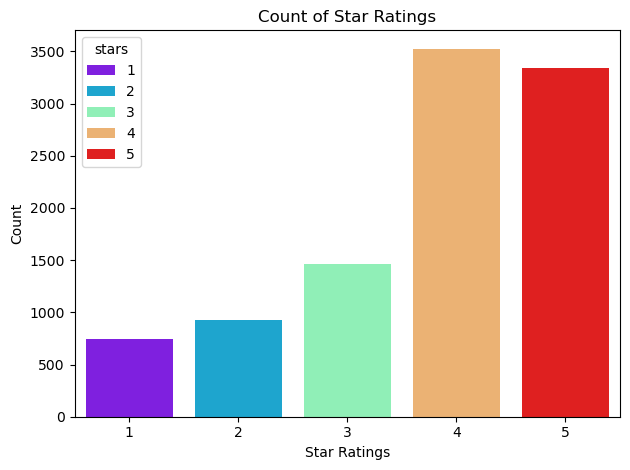

In [5]:
sns.countplot(x='stars', data=yelp, palette='rainbow', hue='stars')
plt.title('Count of Star Ratings')
plt.xlabel('Star Ratings')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Usually reviews are if 4 or 5 star ratings

Lets find relationship between cool, useful, funny, text length

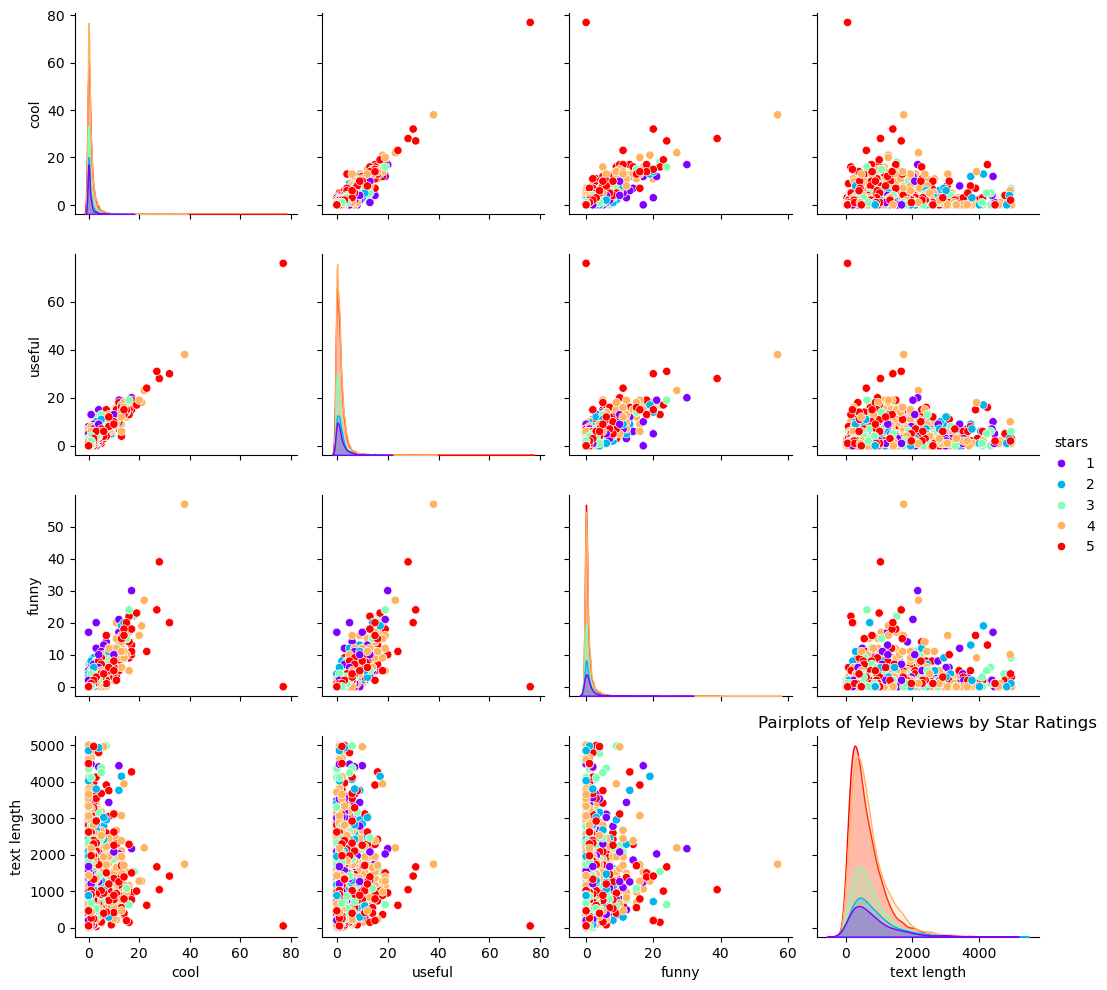

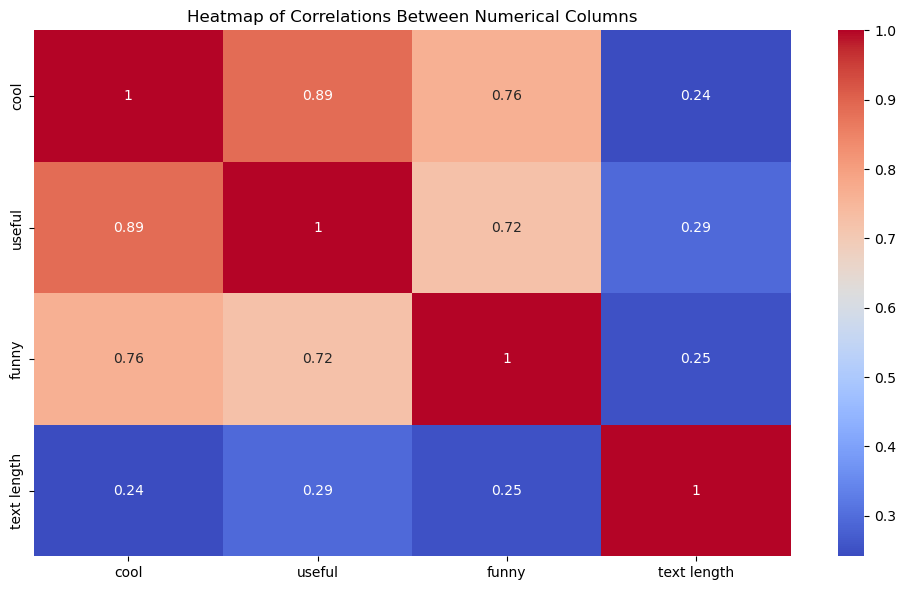

In [13]:
# Pairplots of the data
sns.pairplot(yelp, hue='stars', palette='rainbow')
plt.title('Pairplots of Yelp Reviews by Star Ratings')
plt.tight_layout()
plt.show()

# Making a heatmap of the correlations between the numerical columns
plt.figure(figsize=(10, 6))
sns.heatmap(yelp.drop('stars', axis=1).corr(numeric_only=   True), cmap='coolwarm', annot=True)
plt.title('Heatmap of Correlations Between Numerical Columns')
plt.tight_layout()
plt.show()

1. If the humour(funny) increases, so does its usefulness to reviewers
2. If the reviewers found it cool, then they also found it useful
3. Text lenghts are not worthy to decide if it is cool, useful or funny.

**This data is such a mess, with no clean clear separation between the star ratings!**


In [9]:
yelp.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,text length
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0,889
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0,1345
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0,76
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0,419
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0,469


# Phew! EDA Done!

# Now Real TASK NLP Classification

In [14]:
#Create two objects X and y.
#  X will be the 'text' column of yelp and y will be the 'stars' column of yelp.
X = yelp['text']
y = yelp['stars']

**CountVectorizer** is a great tool provided by the scikit-learn library in Python. It is used to transform a given text into a vector on the basis of the frequency (count) of each word that occurs in the entire text. This is helpful when we have multiple such texts, and we wish to convert each word in each text into vectors (for using in further text analysis).

Here's a brief overview of how it works:

1. Tokenization: Splits the text into individual words (tokens).
2. Vocabulary Building: Creates a vocabulary of all unique words in the corpus.
3. Encoding: Transforms each document into a vector where each element represents the count of a word from the vocabulary in that document.




In [7]:
# Importing CountVectorizer and creating a CountVectorizer object
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [16]:
# Using the fit_transform method on the CountVectorizer object and passing 
# in X (the 'text' column).
X = cv.fit_transform(X)

# Train Test Split

In [5]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Training the Model

Estimator used : MultinomialNB

MultinomialNB is a Naive Bayes classifier for multinomially distributed data. It is one of the variants of the Naive Bayes algorithm provided by the scikit-learn library in Python. This classifier is particularly suited for classification with discrete features (e.g., word counts for text classification).

The Multinomial Naive Bayes algorithm is based on the Bayes theorem and assumes that the features follow a multinomial distribution. It is commonly used for text classification tasks such as spam detection, sentiment analysis, and topic classification.

In [ ]:
# Creating an instance of the estimator
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()

In [20]:
# fitting nb using the training data
nb.fit(X_train, y_train)

MultinomialNB()

# Predictions and Evaluations

In [21]:
# Predicting the values of X_test using nb
predictions = nb.predict(X_test)

In [22]:
# Importing the confusion_matrix and classification_report
from sklearn.metrics import confusion_matrix, classification_report
print('Confusion Matrix:\n')
print(confusion_matrix(y_test, predictions))
print('\n')
print('Classification Report:\n')
print(classification_report(y_test, predictions))  

Confusion Matrix:

[[ 57  35  12  79  37]
 [ 12  20  33 180  28]
 [  6   8  36 350  43]
 [  6   4  21 775 258]
 [  5   5   9 446 535]]


Classification Report:

              precision    recall  f1-score   support

           1       0.66      0.26      0.37       220
           2       0.28      0.07      0.12       273
           3       0.32      0.08      0.13       443
           4       0.42      0.73      0.54      1064
           5       0.59      0.54      0.56      1000

    accuracy                           0.47      3000
   macro avg       0.46      0.34      0.34      3000
weighted avg       0.47      0.47      0.43      3000



# A disappointing Accuracy of 47%

Can we do any better? Yes we can try **TF-IDF** Transformer
`TfidfTransformer` is a feature extraction technique provided by the `scikit-learn` library in Python. It transforms a count matrix (such as one created by `CountVectorizer`) into a normalized Term Frequency-Inverse Document Frequency (TF-IDF) representation. This is useful for text processing tasks as it helps to downscale the importance of words that appear frequently in the corpus and are therefore less informative.

TF-IDF is a statistical measure used to evaluate the importance of a word in a document relative to a collection of documents (corpus). The TF-IDF value increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus.

Here's how you can use `TfidfTransformer`:

1. **Term Frequency (TF)**: The number of times a term appears in a document.
2. **Inverse Document Frequency (IDF)**: The logarithmically scaled inverse fraction of the documents that contain the term.



**TF(t, d) = (Number of times term t appears in document d)/(Total number of terms in document d)**

**IDF(t, D) = log{ (Total number of documents in corpus D)/(Number of documents containing term t)}**

# TF-IDF(t, d, D) = TF(t, d) * IDF (t, D)





In [26]:
#importing the TfidfTransformer and pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline


Creating a **Pipeline** of the following steps

1.CountVectorizer()

2.TfidfTransformer()

3.MultinomialNB()

In `scikit-learn`, a `Pipeline` is a tool that allows you to chain together multiple steps of a machine learning workflow into a single object. This is useful for streamlining the process of transforming data and training models, ensuring that the same sequence of steps is applied consistently during both training and prediction.

A `Pipeline` typically consists of a series of transformers (e.g., `CountVectorizer`, `TfidfTransformer`) followed by an estimator (e.g., `LogisticRegression`, `MultinomialNB`). Each step in the pipeline is executed in order, with the output of one step serving as the input to the next.

Using a `Pipeline` ensures that the same sequence of transformations is applied consistently during both training and prediction, making the workflow more efficient and less error-prone.

In [51]:
pipeline = Pipeline([
    ('bow', CountVectorizer()),  # strings to token integer counts
    ('tfidf', TfidfTransformer()),  # integer counts to weighted TF-IDF scores
    ('classifier', MultinomialNB()),  # train on TF-IDF vectors w/ Naive Bayes classifier
])

In [52]:
# Before using the Pipeline, we need to split the data into a training set and a testing set.
# But our X is already transformed, so we need to define a new X and y for this Pipeline.
X = yelp['text']
y = yelp['stars']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

Fit the Pipeline to the training data (new one!)

In [53]:
#fitting the pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

# Predictions & Evaluation of NLP using Pipeline

In [63]:

# making predictions
predictions = pipeline.predict(X_test) # Predicting the values of X_test using the pipeline

In [31]:
# Evaluating
print('Confusion Matrix:\n')
print(confusion_matrix(y_test, predictions))
print('\n')
print('Classification Report:\n')
print(classification_report(y_test, predictions))

Confusion Matrix:

[[  0   0   0 187  33]
 [  0   0   0 266   7]
 [  0   0   1 422  20]
 [  0   0   0 974  90]
 [  0   0   0 708 292]]


Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       220
           2       0.00      0.00      0.00       273
           3       1.00      0.00      0.00       443
           4       0.38      0.92      0.54      1064
           5       0.66      0.29      0.40      1000

    accuracy                           0.42      3000
   macro avg       0.41      0.24      0.19      3000
weighted avg       0.50      0.42      0.33      3000



/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

# TFID made our life worse with poorer accuracy of 42%

Surely it is because of the mess the data is, as mentioned before!

We may need to club our labels for better accuracy, but what is the point of it?

May be we need to change the ML Model all together. Can we apply ANN on it? 

Lets try!

# USING ANN here

In [6]:
X = yelp['text']
y = yelp['stars']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.3, random_state=101)

In [8]:
X_train = cv.fit_transform(X_train)
X_test = cv.transform(X_test)

In [69]:
X_train.shape

(7000, 24514)

In [70]:
X_test.shape

(3000, 24514)

In [34]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [10]:
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [33]:
# Building the model by Tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy


In [36]:
model = Sequential()
model.add(Dense(units=256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=8, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=5, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
early_stopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
model.fit(x=X_train.toarray(), y=y_train, epochs=100, batch_size=256, validation_data=(X_test.toarray(), y_test), verbose=1, callbacks=[early_stopping])

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.3045 - loss: 1.6138 - val_accuracy: 0.3417 - val_loss: 1.5626
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3471 - loss: 1.5647 - val_accuracy: 0.3337 - val_loss: 1.5114
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.3465 - loss: 1.5275 - val_accuracy: 0.3337 - val_loss: 1.4707
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.3365 - loss: 1.4931 - val_accuracy: 0.3333 - val_loss: 1.4563
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.3431 - loss: 1.4913 - val_accuracy: 0.3333 - val_loss: 1.4328
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3347 - loss: 1.4640 - val_accuracy: 0.3333 - val_loss: 1.4041
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.3449 - loss: 1.4496 - val_accuracy: 0.3333 - val_loss: 1.3502
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.3379 - loss: 1.4297 - val_accuracy: 0.

In [39]:
loss, accuracy = model.evaluate(X_test.toarray(), y_test, verbose=0)
print(f'Loss: {loss}, Accuracy: {accuracy}')

Loss: 1.3426368236541748, Accuracy: 0.4676666557788849


<Axes: >

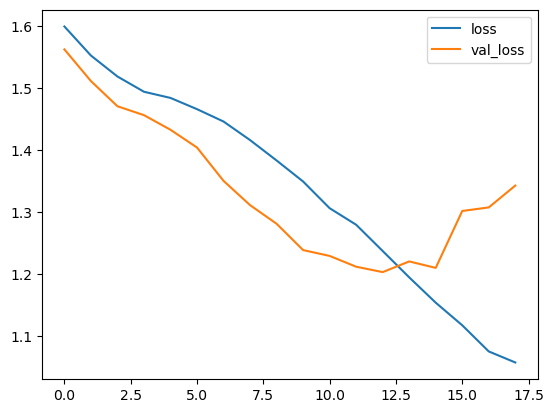

In [38]:
losses = pd.DataFrame(model.history.history)
losses[['loss', 'val_loss']].plot()

As both losses are falling, it seems no over fitting here till epoch 13

Can we do better? Probably by changing the model itself? Or perhaps the data is itself very complicated.

In [74]:
# Making predictions
predictions = model.predict(X_test.toarray()) #Gives proportion of each class
predictions = pd.DataFrame(predictions, columns=['0', '1', '2', '3', '4'])
predictions

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,0,1,2,3,4
0,2.821846e-01,3.087244e-01,4.019300e-01,0.006443,0.000718
1,5.554720e-02,6.843268e-02,1.799432e-01,0.507103,0.188974
2,8.767901e-03,1.219000e-02,5.101138e-02,0.647192,0.280839
3,8.956823e-13,5.011997e-12,3.525370e-09,0.546784,0.453216
4,2.276127e-06,5.386557e-06,1.418235e-04,0.645987,0.353864
...,...,...,...,...,...
2995,3.295507e-26,1.162593e-24,7.520675e-19,0.337051,0.662949
2996,0.000000e+00,0.000000e+00,0.000000e+00,0.018291,0.981709
2997,4.914939e-02,6.096101e-02,1.659555e-01,0.524298,0.199636
2998,3.739817e-12,1.915457e-11,9.869031e-09,0.556709,0.443291


In [81]:
predicted_classes = predictions.idxmax(axis=1)
predicted_classes = predicted_classes.astype(int)
predicted_classes

0       2
1       3
2       3
3       3
4       3
       ..
2995    4
2996    4
2997    3
2998    3
2999    4
Length: 3000, dtype: int64

In [82]:
# Evaluate model by confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
print('Confusion Matrix:\n')
print(confusion_matrix(y_test, predicted_classes))
print('\n')
print('Classification Report:\n')
print(classification_report(y_test, predicted_classes))

Confusion Matrix:

[[  8  15 168  18  11]
 [  2   5 221  42   3]
 [  0   1 237 183  22]
 [  0   1 150 710 203]
 [  0   0  54 425 521]]


Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.04      0.07       220
           1       0.23      0.02      0.03       273
           2       0.29      0.53      0.37       443
           3       0.52      0.67      0.58      1064
           4       0.69      0.52      0.59      1000

    accuracy                           0.49      3000
   macro avg       0.50      0.36      0.33      3000
weighted avg       0.53      0.49      0.47      3000



# Accuracy is just 49% :(

# Lets increase the number of features and factor in Cool, Useful, Funny and Text Length

May be they can help improve the accuracy.

In [86]:
# Defining the X and y again
X = yelp[['text', 'text length', 'cool', 'useful', 'funny']]
y = yelp['stars']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.3, random_state=101)

In [87]:
# Using count vectorizer to transform the text column only
X_train_text = cv.fit_transform(X_train['text'])
X_test_text = cv.transform(X_test['text'])


In [88]:
# Combining the transformed text column with the other columns
from scipy.sparse import hstack
X_train = hstack([X_train_text, X_train.drop('text', axis=1)])
X_test = hstack([X_test_text, X_test.drop('text', axis=1)])

In [92]:
# Using the LabelEncoder to transform the y_train and y_test
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [93]:
# Scaling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.toarray())
X_test = scaler.transform(X_test.toarray())

In [94]:
# Building the model
model_3 = Sequential()
model_3.add(Dense(units=256, activation='relu', input_shape=(X_train.shape[1],)))
model_3.add(Dropout(0.5))
model_3.add(Dense(units=128, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(units=64, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(units=32, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(units=16, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(units=8, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(units=5, activation='softmax'))
model_3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [99]:
early_stopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
model_3.fit(x=X_train, y=y_train, epochs=600, batch_size=256, validation_data=(X_test, y_test), verbose=1, callbacks=[early_stopping])

evaluation = model_3.evaluate(X_test, y_test, verbose=1)
print(f'Model Evaluation: {evaluation}')

Epoch 1/600
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3584 - loss: 1.3525 - val_accuracy: 0.3547 - val_loss: 1.3646
Epoch 2/600
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.3522 - loss: 1.3536 - val_accuracy: 0.3547 - val_loss: 1.3544
Epoch 3/600
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.3596 - loss: 1.3540 - val_accuracy: 0.3547 - val_loss: 1.3583
Epoch 4/600
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3660 - loss: 1.3470 - val_accuracy: 0.3547 - val_loss: 1.3567
Epoch 5/600
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3637 - loss: 1.3378 - val_accuracy: 0.3553 - val_loss: 1.3350
Epoch 6/600
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3692 - loss: 1.3363 - val_accuracy: 0.3607 - val_loss: 1.3124
Epoch 7/600
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3823 - loss: 1.3039 - val_accuracy: 0.3660 - val_loss: 1.2984
Epoch 8/600
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.3844 - loss: 1.2799 - val_accuracy: 0.

In [108]:
# Making predictions
predictions = model_3.predict(X_test) #Gives proportion of each class
predictions = pd.DataFrame(predictions, columns=['0', '1', '2', '3', '4'])
predicted_classes = predictions.idxmax(axis=1)
predicted_classes = predicted_classes.astype(int)


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [110]:
# Evaluate model by confusion matrix and classification report
print('Confusion Matrix:\n')
print(confusion_matrix(y_test, predicted_classes))
print('\n')
print('Classification Report:\n')
print(classification_report(y_test, predicted_classes))

Confusion Matrix:

[[  0   0 152  68   0]
 [  0   0 163 110   0]
 [  0   0 141 302   0]
 [  0   0 101 963   0]
 [  0   0  41 959   0]]


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       220
           1       0.00      0.00      0.00       273
           2       0.24      0.32      0.27       443
           3       0.40      0.91      0.56      1064
           4       0.00      0.00      0.00      1000

    accuracy                           0.37      3000
   macro avg       0.13      0.24      0.17      3000
weighted avg       0.18      0.37      0.24      3000



/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

# Accuracy is just 37%.
Major loss of time and effort here.

# HARD LUCK!
Not everyday is a victory. Lets blame the data and close this. :P